Initializing Architecture and VRAM...


c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
c:\Users\dil\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:690: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn

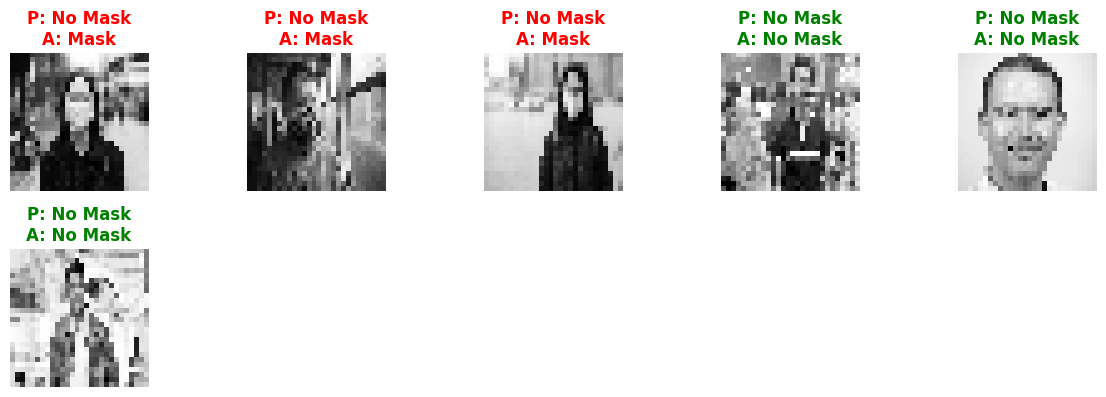

In [3]:
import os
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import cuda

# ==========================================
# 1. DATASET LOADER
# ==========================================
def load_data(path, img_size=28):
    images, labels = [], []
    
    if not os.path.exists(path):
        print(f"❌ Error: The folder '{path}' was not found.")
        return np.array([]), np.array([])

    for label, folder in enumerate(["mask", "unmask"]):
        folder_path = os.path.join(path, folder)
        if not os.path.exists(folder_path): continue
        
        for file in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, file), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)

    # Vectorized normalization (0.0 to 1.0)
    X = np.array(images, dtype=np.float32) / 255.0
    y = np.array(labels, dtype=np.int32) 
    return X, y

# ==========================================
# 2. RAW CUDA KERNELS (3D Architecture)
# ==========================================
@cuda.jit
def conv2d(input_img, filters, output):
    x, y, f = cuda.grid(3)
    # 28x28 input with 3x3 kernel (no padding) = 26x26 output
    if x < 26 and y < 26 and f < filters.shape[0]:
        s = 0.0
        for i in range(3):
            for j in range(3):
                s += input_img[x+i, y+j] * filters[f, i, j]
        output[x, y, f] = s

@cuda.jit
def relu(data):
    x, y, f = cuda.grid(3)
    if x < data.shape[0] and y < data.shape[1] and f < data.shape[2]:
        if data[x, y, f] < 0.0:
            data[x, y, f] = 0.0

@cuda.jit
def maxpool(input_img, output):
    x, y, f = cuda.grid(3)
    # MaxPool cuts 26x26 down to 13x13
    if x < 13 and y < 13 and f < input_img.shape[2]:
        in_x, in_y = x * 2, y * 2
        max_val = -999999.0
        for i in range(2):
            for j in range(2):
                val = input_img[in_x+i, in_y+j, f]
                if val > max_val:
                    max_val = val
        output[x, y, f] = max_val

@cuda.jit
def fully_connected_sigmoid(pooled_features, weights, bias, output):
    # Single thread reduction for the final probability
    if cuda.grid(1) == 0:
        s = bias[0]
        idx = 0
        for f in range(8):
            for x in range(13):
                for y in range(13):
                    s += pooled_features[x, y, f] * weights[idx]
                    idx += 1
        
        # Sigmoid with domain safety limits
        if s < -70.0: output[0] = 0.0
        elif s > 70.0: output[0] = 1.0
        else: output[0] = 1.0 / (1.0 + math.exp(-s))

# ==========================================
# 3. GPU INITIALIZATION & MEMORY ALLOCATION
# ==========================================
print("Initializing Architecture and VRAM...")

# 1. Generate Dummy Weights (Replace with trained weights later)
filters_weights = np.random.uniform(-0.1, 0.1, (8, 3, 3)).astype(np.float32)
dense_weights = np.random.uniform(-0.1, 0.1, (1352,)).astype(np.float32)
dense_bias = np.random.uniform(-0.1, 0.1, (1,)).astype(np.float32)

# 2. Move Weights to GPU
d_filters = cuda.to_device(filters_weights) 
d_dense_w = cuda.to_device(dense_weights)   
d_dense_b = cuda.to_device(dense_bias)      

# 3. Pre-allocate intermediate tensors
d_input = cuda.device_array((28, 28), dtype=np.float32)
d_conv  = cuda.device_array((26, 26, 8), dtype=np.float32) 
d_pool  = cuda.device_array((13, 13, 8), dtype=np.float32) 
d_final_prob = cuda.device_array((1,), dtype=np.float32)

# 4. Define Thread Blocks
threads3d = (8, 8, 8)
blocks_conv = (math.ceil(26/8), math.ceil(26/8), math.ceil(8/8))
blocks_pool = (math.ceil(13/8), math.ceil(13/8), math.ceil(8/8))

# ==========================================
# 4. PREDICTION FUNCTION
# ==========================================
def predict_image(img):
    """Runs a single 28x28 grayscale image through the GPU Pipeline."""
    # Ensure float32 to prevent Numba typing errors
    d_input.copy_to_device(img.astype(np.float32))

    # Execute Kernels
    conv2d[blocks_conv, threads3d](d_input, d_filters, d_conv)
    relu[blocks_conv, threads3d](d_conv)
    maxpool[blocks_pool, threads3d](d_conv, d_pool)
    fully_connected_sigmoid[1, 1](d_pool, d_dense_w, d_dense_b, d_final_prob)

    # Fetch Probability
    probability = d_final_prob.copy_to_host()[0]
    return 1 if probability > 0.5 else 0

# ==========================================
# 5. EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    # Load the Data
    X, y = load_data("processed_dataset")
    
    if len(X) > 0:
        class_names = ["Mask", "No Mask"]
        num_images_to_plot = min(len(X), 20) 
        
        plt.figure(figsize=(12, 8))
        
        for i in range(num_images_to_plot):
            pred = predict_image(X[i])
            actual = y[i]

            plt.subplot(4, 5, i+1)
            plt.imshow(X[i], cmap='gray')
            plt.axis("off")

            color = "green" if pred == actual else "red"
            plt.title(f"P: {class_names[pred]}\nA: {class_names[actual]}", color=color, fontweight="bold")

        plt.tight_layout()
        plt.show()